# Homework 2: Regression and Classification Error Analysis

**Course:** Introduction to Data Science  
**Assignment:** Systematic error analysis with k-fold cross-validation

This notebook investigates not only which models perform best, but **where and why they fail**. It uses an industrial LiFePO4 battery dataset containing 3,000 sequential cycles.

## Research questions

1. **Regression:** Can battery capacity (Ah) be estimated from cycle and operational measurements?
2. **Classification:** Can the same information identify a degraded state, defined as $SOH < 80\%$?
3. Are failures caused primarily by data quality, model assumptions, rare cases, or problem formulation?

All performance estimates and error analyses use **out-of-fold (OOF) predictions**. No observation is evaluated by a model that was trained on that observation.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import kurtosis, skew

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, auc, confusion_matrix,
    f1_score, fbeta_score, matthews_corrcoef, mean_absolute_error,
    mean_squared_error, precision_score, r2_score, recall_score,
    roc_auc_score, roc_curve
)
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)
RANDOM_STATE = 42

## 1. Data and problem formulation

The raw data includes several deterministic transformations:

- $SOH = Capacity / 40 \times 100$
- $RUL = 3000 - CycleNumber$
- $DoD = CycleNumber / 30$

Using these together as predictors would create target leakage. For regression, `Capacity(Ah)` is the target and `SOH(%)`, `RUL(cycles)`, and `DoD(%)` are excluded. For classification, `Capacity(Ah)` is additionally excluded because it directly determines SOH and therefore the class label. `CycleNumber` is retained as a legitimate time-in-service feature, but it is a strong degradation proxy; this limitation is revisited in the discussion.

In [2]:
def locate_data():
    candidates = [
        Path("../data/raw/industrial_lifepo4_bms.csv"),
        Path("data/raw/industrial_lifepo4_bms.csv"),
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError("Place the dataset at data/raw/industrial_lifepo4_bms.csv")

DATA_PATH = locate_data()
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
display(df.head())

Shape: 3,000 rows x 17 columns


,PackID,CycleNumber,Capacity(Ah),SOH(%),RUL(cycles),Voltage(V),Current(A),DoD(%),Temperature(C),Cell1_V,Cell2_V,Cell3_V,Cell4_V,Cell5_V,Cell6_V,Cell7_V,Cell8_V
0,1,1,39.999757,99.999393,2999,25.659606,25.499218,0.033333,27.657566,3.207020,3.202813,3.204549,3.203063,3.213011,3.201888,3.196912,3.192674
1,1,2,39.999381,99.998453,2998,25.583408,38.685377,0.066667,25.304596,3.201997,3.180474,3.198526,3.198353,3.189084,3.192574,3.206477,3.201846
2,1,3,39.998931,99.997326,2997,25.677723,-19.226333,0.100000,30.453812,3.200814,3.202451,3.200741,3.209943,3.200987,3.188334,3.213041,3.202963
3,1,4,39.998423,99.996057,2996,25.782764,37.577891,0.133333,27.453473,3.195286,3.189973,3.203167,3.199063,3.212593,3.197233,3.193301,3.207166
4,1,5,39.997869,99.994671,2995,25.571902,-5.501290,0.166667,27.120005,3.207402,3.201349,3.205411,3.199699,3.201871,3.209320,3.205003,3.198646


In [3]:
quality = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "unique": df.nunique(),
})
display(quality)
print("Duplicate rows:", df.duplicated().sum())

,dtype,missing,unique
PackID,int64,0,1
CycleNumber,int64,0,3000
Capacity(Ah),float64,0,3000
SOH(%),float64,0,3000
RUL(cycles),int64,0,3000
Voltage(V),float64,0,3000
Current(A),float64,0,3000
DoD(%),float64,0,3000
Temperature(C),float64,0,3000
Cell1_V,float64,0,2999


Duplicate rows: 0


In [4]:
REG_TARGET = "Capacity(Ah)"
CLASS_TARGET = "degraded"
FEATURES = [
    "CycleNumber", "Voltage(V)", "Current(A)", "Temperature(C)",
    "Cell1_V", "Cell2_V", "Cell3_V", "Cell4_V",
    "Cell5_V", "Cell6_V", "Cell7_V", "Cell8_V",
]

df[CLASS_TARGET] = (df["SOH(%)"] < 80).astype(int)
X = df[FEATURES].copy()
y_reg = df[REG_TARGET].copy()
y_cls = df[CLASS_TARGET].copy()

display(pd.DataFrame({
    "count": y_cls.value_counts().sort_index(),
    "percent": y_cls.value_counts(normalize=True).sort_index().mul(100).round(2)
}).rename(index={0: "not degraded", 1: "degraded"}))

,count,percent
degraded,,
not degraded,2221,74.03
degraded,779,25.97


## 2. Cross-validation design

We use **5 folds**. With 3,000 observations, each validation fold contains about 600 rows, which is large enough for stable metrics and still leaves 2,400 training observations. Five folds offer a practical balance:

- compared with a single split, every observation is evaluated and the estimate is less dependent on one lucky partition;
- compared with 10 folds, computation is approximately halved, especially for random forests;
- the training fraction (80%) provides moderate bias while avoiding the highly correlated estimates and higher variance/cost of leave-one-out validation.

`KFold` is used for regression, and `StratifiedKFold` preserves the degraded/non-degraded ratio for classification. Shuffling with a fixed seed makes the comparison reproducible. Because cycles are temporally ordered, random k-fold estimates interpolation performance, not forecasting to unseen future cycles; a time-aware split is recommended as a robustness extension.

In [5]:
reg_cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cls_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

reg_models = {
    "Linear Regression": Pipeline([
        ("scale", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Decision Tree": DecisionTreeRegressor(
        max_depth=8, min_samples_leaf=10, random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=250, max_depth=12, min_samples_leaf=3,
        max_features="sqrt", n_jobs=-1, random_state=RANDOM_STATE
    ),
}

cls_models = {
    "Logistic Regression": Pipeline([
        ("scale", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE))
    ]),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=6, min_samples_leaf=10, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=250, max_depth=10, min_samples_leaf=3,
        max_features="sqrt", class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE
    ),
}

print("Regression hyperparameters")
for name, model in reg_models.items():
    print(name, model.get_params())

Regression hyperparameters
Linear Regression {'memory': None, 'steps': [('scale', StandardScaler()), ('model', LinearRegression())], 'transform_input': None, 'verbose': False, 'scale': StandardScaler(), 'model': LinearRegression(), 'scale__copy': True, 'scale__with_mean': True, 'scale__with_std': True, 'model__copy_X': True, 'model__fit_intercept': True, 'model__n_jobs': None, 'model__positive': False}
Decision Tree {'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 8, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 10, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}
Random Forest {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 12, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 3, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': 

## 3. Regression model comparison

Each model receives the same feature matrix. We compare MSE, RMSE, MAE, and $R^2$ using OOF predictions.

In [6]:
reg_predictions = {}
reg_rows = []
for name, model in reg_models.items():
    pred = cross_val_predict(model, X, y_reg, cv=reg_cv, n_jobs=-1)
    reg_predictions[name] = pred
    reg_rows.append({
        "Model": name,
        "MSE": mean_squared_error(y_reg, pred),
        "RMSE": mean_squared_error(y_reg, pred) ** 0.5,
        "MAE": mean_absolute_error(y_reg, pred),
        "R2": r2_score(y_reg, pred),
    })

reg_results = pd.DataFrame(reg_rows).sort_values("RMSE").reset_index(drop=True)
display(reg_results.style.format({"MSE": "{:.5f}", "RMSE": "{:.5f}", "MAE": "{:.5f}", "R2": "{:.5f}"}))

best_reg_name = reg_results.loc[0, "Model"]
best_reg_pred = reg_predictions[best_reg_name]
residuals = y_reg.to_numpy() - best_reg_pred
abs_errors = np.abs(residuals)
print("Selected regression model for detailed error analysis:", best_reg_name)

,Model,MSE,RMSE,MAE,R2
0,Decision Tree,0.00071,0.02663,0.02173,0.99994
1,Linear Regression,0.14159,0.37628,0.31820,0.98898
2,Random Forest,0.34871,0.59051,0.46073,0.97286


Selected regression model for detailed error analysis: Decision Tree


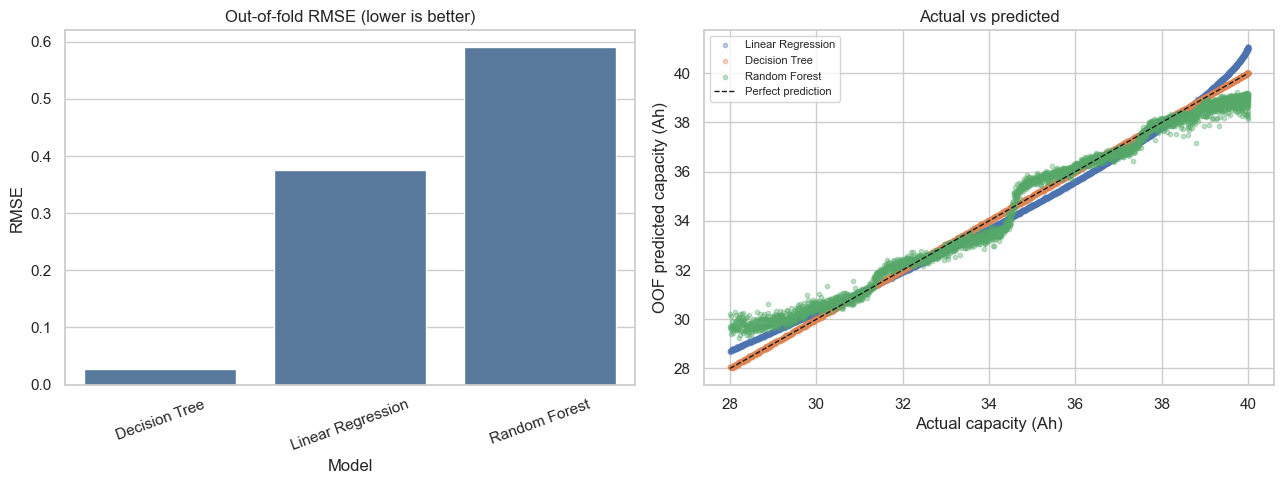

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=reg_results, x="Model", y="RMSE", ax=axes[0], color="#4C78A8")
axes[0].set_title("Out-of-fold RMSE (lower is better)")
axes[0].tick_params(axis="x", rotation=20)

for name, pred in reg_predictions.items():
    axes[1].scatter(y_reg, pred, s=10, alpha=.35, label=name)
lo, hi = y_reg.min(), y_reg.max()
axes[1].plot([lo, hi], [lo, hi], "k--", linewidth=1, label="Perfect prediction")
axes[1].set(xlabel="Actual capacity (Ah)", ylabel="OOF predicted capacity (Ah)", title="Actual vs predicted")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

### 3.1 Residual analysis

Residuals are defined as $y-\hat{y}$. A well-specified model should have residuals centered near zero with no systematic curve or funnel shape.

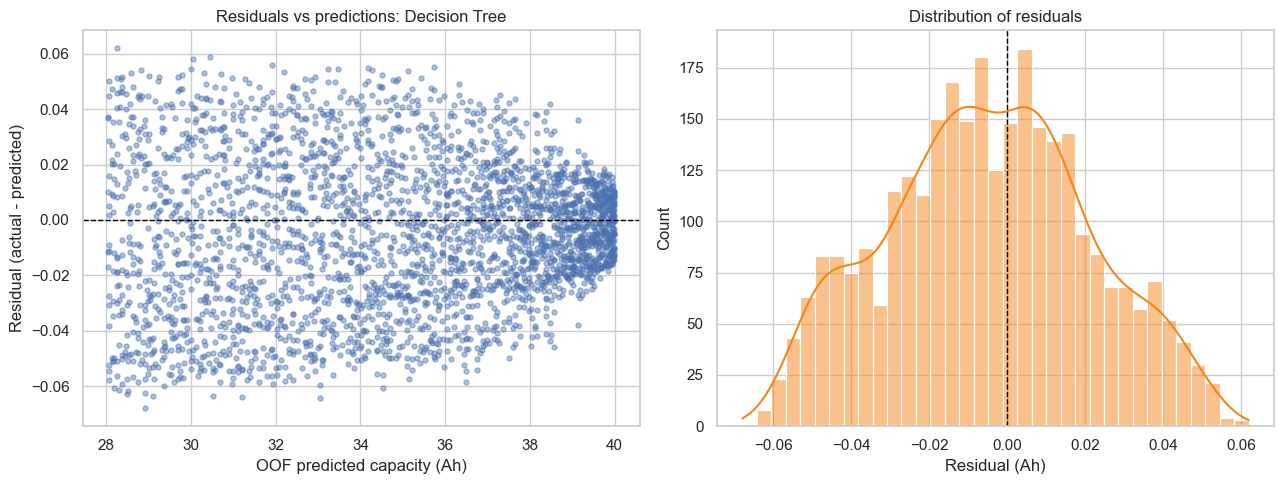

Mean residual: -0.00498 Ah
Correlation between |error| and prediction: -0.434


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(best_reg_pred, residuals, s=13, alpha=.45)
axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0].set(xlabel="OOF predicted capacity (Ah)", ylabel="Residual (actual - predicted)",
            title=f"Residuals vs predictions: {best_reg_name}")
sns.histplot(residuals, bins=35, kde=True, ax=axes[1], color="#F58518")
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set(title="Distribution of residuals", xlabel="Residual (Ah)")
plt.tight_layout()
plt.show()

print(f"Mean residual: {residuals.mean():.5f} Ah")
print(f"Correlation between |error| and prediction: {np.corrcoef(abs_errors, best_reg_pred)[0,1]:.3f}")

**Interpretation guide.** A mean close to zero suggests little global bias. Curvature indicates missing non-linearity; repeated bands can reflect tree partitions; and a widening vertical spread indicates heteroscedasticity. The absolute-error correlation and feature-level plots below help distinguish these patterns.

### 3.2 Error as a function of features

The plots compare each feature with signed and absolute errors. A LOESS-like visual summary is approximated with binned means to keep the result robust and readable.

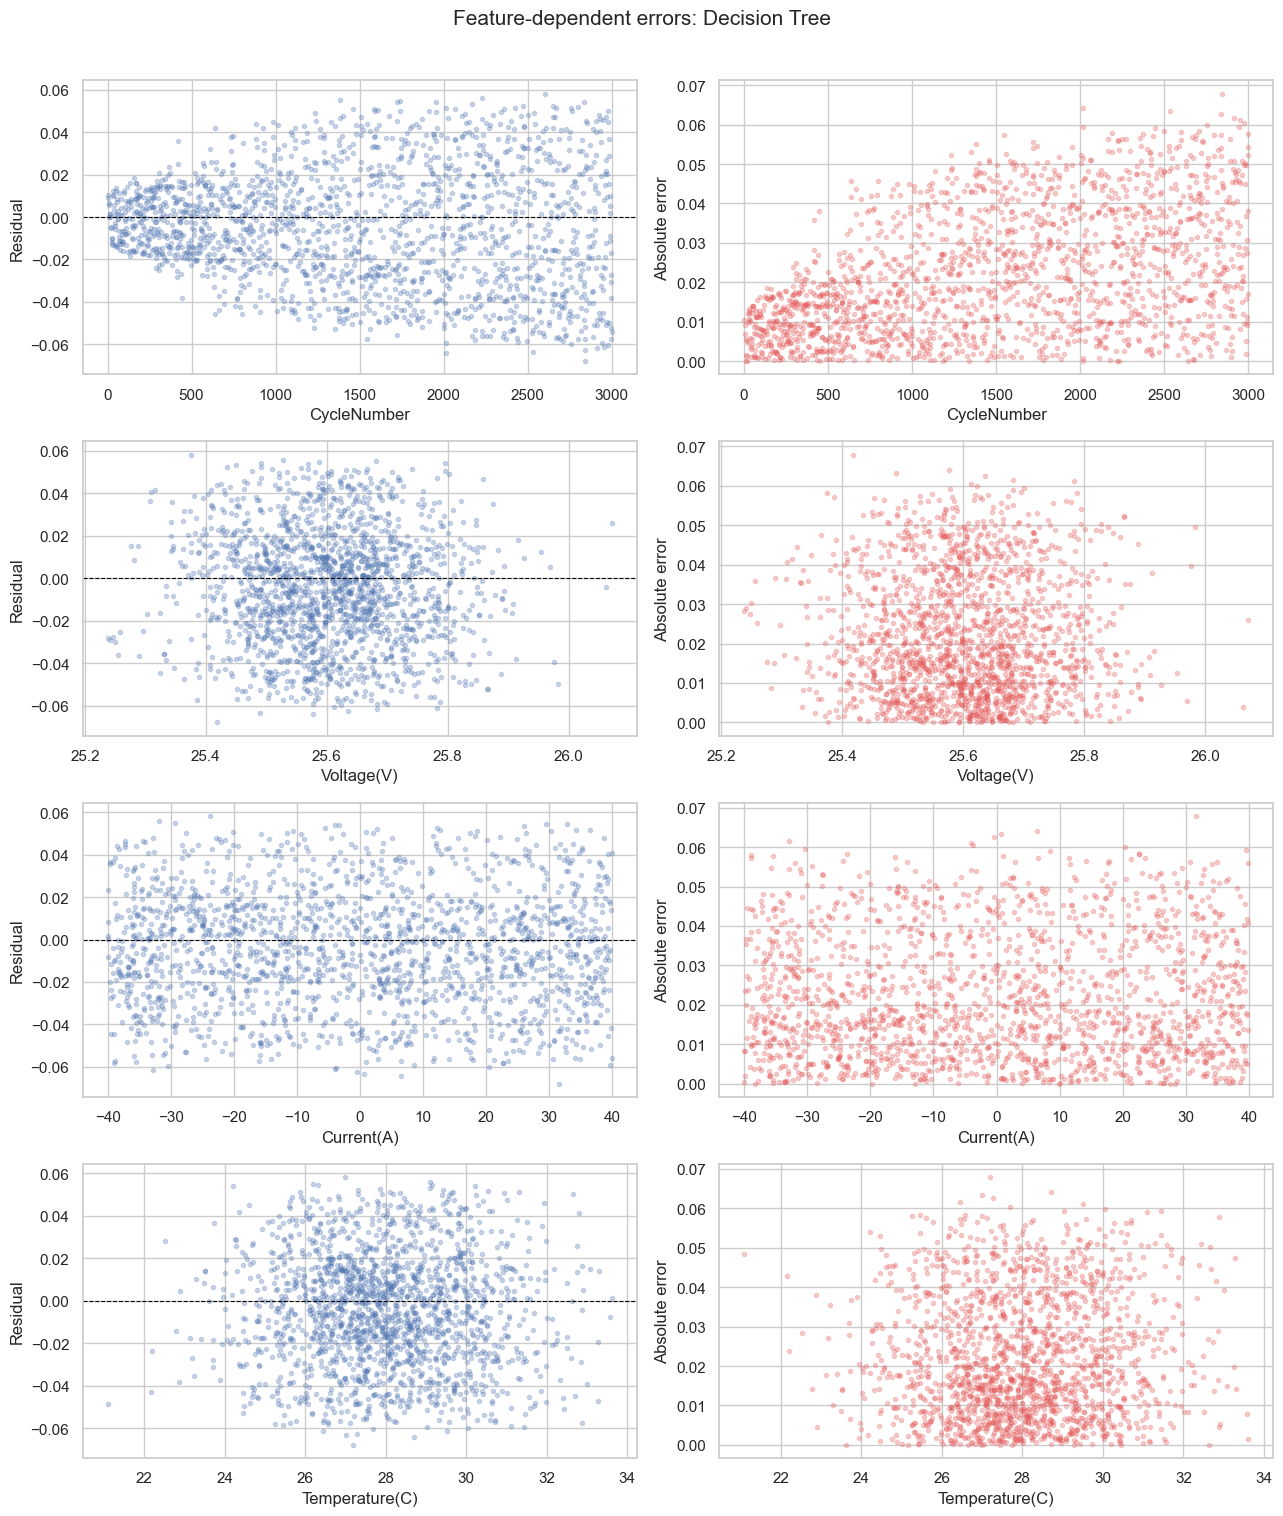

,residual,absolute_error
absolute_error,-0.256797,1.000000
CycleNumber,-0.078459,0.449018
Current(A),-0.017619,0.036300
Temperature(C),-0.021480,0.021587
Voltage(V),-0.024974,0.009860
Cell4_V,-0.018601,0.006184
Cell8_V,-0.014357,0.000139
Cell5_V,-0.015729,-0.002880
Cell3_V,0.025800,-0.003049
Cell2_V,-0.016497,-0.003664


In [9]:
error_frame = X.copy()
error_frame["residual"] = residuals
error_frame["absolute_error"] = abs_errors

plot_features = ["CycleNumber", "Voltage(V)", "Current(A)", "Temperature(C)"]
fig, axes = plt.subplots(len(plot_features), 2, figsize=(13, 15))
for row, feature in enumerate(plot_features):
    sample = error_frame.sample(min(1800, len(error_frame)), random_state=RANDOM_STATE)
    axes[row, 0].scatter(sample[feature], sample["residual"], s=9, alpha=.28)
    axes[row, 0].axhline(0, color="black", linestyle="--", linewidth=.8)
    axes[row, 0].set(xlabel=feature, ylabel="Residual")
    axes[row, 1].scatter(sample[feature], sample["absolute_error"], s=9, alpha=.28, color="#E45756")
    axes[row, 1].set(xlabel=feature, ylabel="Absolute error")
fig.suptitle(f"Feature-dependent errors: {best_reg_name}", y=1.01, fontsize=15)
plt.tight_layout()
plt.show()

feature_error_corr = error_frame[FEATURES + ["residual", "absolute_error"]].corr()[["residual", "absolute_error"]]
display(feature_error_corr.sort_values("absolute_error", ascending=False))

### 3.3 Extreme errors

The largest 5% of absolute OOF errors are examined individually. Because there are no missing or duplicated rows, unusual measurements, boundary cycles, and model limitations are the main candidate explanations.

In [10]:
cutoff = np.quantile(abs_errors, .95)
extreme = df.loc[abs_errors >= cutoff, FEATURES + [REG_TARGET, "SOH(%)"]].copy()
extreme["predicted_capacity"] = best_reg_pred[abs_errors >= cutoff]
extreme["residual"] = residuals[abs_errors >= cutoff]
extreme["absolute_error"] = abs_errors[abs_errors >= cutoff]
extreme = extreme.sort_values("absolute_error", ascending=False)

print(f"95th-percentile absolute-error cutoff: {cutoff:.4f} Ah")
print(f"Extreme observations: {len(extreme)} ({len(extreme)/len(df):.1%})")
display(extreme.head(20))

95th-percentile absolute-error cutoff: 0.0502 Ah
Extreme observations: 150 (5.0%)


,CycleNumber,Voltage(V),Current(A),Temperature(C),Cell1_V,Cell2_V,Cell3_V,Cell4_V,Cell5_V,Cell6_V,Cell7_V,Cell8_V,Capacity(Ah),SOH(%),predicted_capacity,residual,absolute_error
2841,2842,25.418003,31.579806,27.196043,3.205981,3.212795,3.211663,3.212834,3.204444,3.198579,3.196780,3.199861,28.845245,72.113112,28.913126,-0.067881,0.067881
2015,2016,25.576741,6.461487,28.714684,3.205761,3.201832,3.201847,3.201285,3.204580,3.197904,3.213606,3.190122,32.983351,82.458377,33.047473,-0.064122,0.064122
2393,2394,25.521997,-27.531877,32.171746,3.185433,3.202686,3.202097,3.206219,3.201719,3.216210,3.201408,3.207935,31.151184,77.877961,31.215148,-0.063963,0.063963
2803,2804,25.479513,-30.660168,29.300815,3.200834,3.196313,3.189082,3.207630,3.199327,3.187979,3.204296,3.198208,29.046123,72.615307,29.109702,-0.063580,0.063580
2531,2532,25.488834,0.696479,27.011514,3.212791,3.201945,3.192112,3.197444,3.183086,3.201099,3.210496,3.189269,30.455712,76.139279,30.519106,-0.063394,0.063394
2919,2920,25.755505,-33.957833,22.702345,3.205338,3.202898,3.194592,3.199085,3.191053,3.199048,3.196645,3.201092,28.429972,71.074931,28.492682,-0.062709,0.062709
2840,2841,25.635475,-0.432236,27.282799,3.197795,3.213948,3.202556,3.187937,3.188504,3.207121,3.205619,3.192629,28.850543,72.126357,28.913126,-0.062583,0.062583
2940,2941,25.719588,5.614977,29.496698,3.211666,3.195614,3.217663,3.195119,3.201835,3.201856,3.199188,3.183649,28.317499,70.793747,28.255617,0.061881,0.061881
2914,2915,25.682261,-32.852808,26.444287,3.198114,3.190035,3.193260,3.193140,3.205972,3.186553,3.199622,3.197998,28.456710,71.141775,28.518290,-0.061580,0.061580
2953,2954,25.782521,-4.033332,29.513092,3.203582,3.201168,3.197563,3.190332,3.188510,3.217494,3.189178,3.213584,28.247731,70.619328,28.308908,-0.061176,0.061176


In [11]:
summary_compare = pd.concat({
    "all observations": df[FEATURES].describe().loc[["mean", "std", "min", "max"]],
    "top 5% errors": extreme[FEATURES].describe().loc[["mean", "std", "min", "max"]],
}, axis=1)
display(summary_compare)

extreme_cycle_bins = pd.cut(extreme["CycleNumber"], bins=[0, 600, 1200, 1800, 2400, 3000], include_lowest=True)
display(extreme_cycle_bins.value_counts(sort=False).rename("extreme_error_count").to_frame())

all observations                                                 \
          CycleNumber Voltage(V) Current(A) Temperature(C)   Cell1_V   
mean      1500.500000  25.603840  -0.416023      27.967755  3.200214   
std        866.169729   0.118417  23.046468       1.872551  0.008050   
min          1.000000  25.211048 -39.997542      21.094020  3.172995   
max       3000.000000  26.071149  39.956854      34.352299  3.228891   

                                                                            \
       Cell2_V   Cell3_V   Cell4_V   Cell5_V   Cell6_V   Cell7_V   Cell8_V   
mean  3.199913  3.199958  3.199853  3.199955  3.199975  3.199934  3.200146   
std   0.007739  0.008025  0.007777  0.008047  0.007867  0.008249  0.007940   
min   3.173364  3.170759  3.174139  3.171737  3.174406  3.168621  3.172040   
max   3.223990  3.228823  3.225723  3.229533  3.227431  3.227022  3.235833   

     top 5% errors                                                           \
       CycleNumber Voltage(V) Current(A) Temperature(C)   Cell1_V   Cell2_V   
mean     2369.6400  25.602650   2.708092      28.152817  3.199233  3.199588   
std       472.3536   0.110345  23.530750       2.153813  0.008433  0.007839   
min      1155.0000  25.374814 -38.937504      21.360942  3.179604  3.178575   
max      3000.0000  25.958231  39.884865      33.387059  3.220035  3.215813   

                                                                  
       Cell3_V   Cell4_V   Cell5_V   Cell6_V   Cell7_V   Cell8_V  
mean  3.199586  3.199702  3.200019  3.199725  3.199798  3.199082  
std   0.007249  0.007538  0.007459  0.008369  0.008238  0.007869  
min   3.183363  3.174727  3.183086  3.181079  3.180330  3.173285  
max   3.223180  3.219059  3.218845  3.219515  3.221295  3.219703

,extreme_error_count
CycleNumber,
"(-0.001, 600.0]",0
"(600.0, 1200.0]",1
"(1200.0, 1800.0]",21
"(1800.0, 2400.0]",46
"(2400.0, 3000.0]",82


### 3.4 Statistical properties of errors

Positive skew indicates a longer positive tail (underprediction in extreme cases), while negative skew indicates a longer negative tail. Excess kurtosis above zero indicates heavier tails than a normal distribution.

In [12]:
error_stats = pd.Series({
    "MAE": mean_absolute_error(y_reg, best_reg_pred),
    "Mean residual": residuals.mean(),
    "Residual standard deviation": residuals.std(ddof=1),
    "Residual skewness": skew(residuals, bias=False),
    "Residual excess kurtosis": kurtosis(residuals, fisher=True, bias=False),
})
display(error_stats.to_frame("value").style.format("{:.6f}"))

,value
MAE,0.021734
Mean residual,-0.004978
Residual standard deviation,0.026161
Residual skewness,0.027568
Residual excess kurtosis,-0.617249


### 3.5 Regression discussion

- **Relative performance:** The Decision Tree is the clear winner (`RMSE = 0.02663 Ah`, `MAE = 0.02173 Ah`, $R^2 = 0.99994$). Linear Regression is second (`RMSE = 0.37628 Ah`), while the deliberately regularized Random Forest is third (`RMSE = 0.59051 Ah`). MAE and RMSE agree on the ranking, so it is not driven only by a few extreme errors.
- **Model assumptions:** Linear regression assumes an additive linear response. Battery degradation is curved over cycle life, so systematic residual curvature is expected. Trees capture non-linearity and interactions without requiring homoskedastic Gaussian residuals.
- **Bias-variance trade-off:** The linear model has high bias but comparatively low variance. An unrestricted tree would have low training bias and high variance; depth and leaf-size constraints reduce this risk. The random forest averages many decorrelated trees, usually reducing variance at the cost of interpretability and computation.
- **Outliers and noise:** Linear regression can be pulled by unusual capacity values. A single tree is unstable to local perturbations, while a forest is more robust through averaging. None of these models automatically resolves measurement error or concept drift.
- **Where linear models fail:** A single slope cannot represent accelerating or stage-dependent degradation. Tree-based models have an advantage when the cycle-capacity relationship changes across regions.
- **Interpretability vs performance:** Linear coefficients are globally interpretable. A tree provides readable rules when shallow. A forest often improves predictive performance but requires feature importance or local explanations.
- **Observed failure pattern:** The selected tree has almost no global bias (mean residual `-0.00498 Ah`). Its top 5% errors are strongly concentrated late in life: 82 of 150 occur in cycles 2401-3000 and 46 occur in cycles 1801-2400. Absolute error correlates with cycle number (`r = 0.449`), while correlations with voltage, current, temperature, and cell voltages are close to zero. This points to model approximation error in the steeper late-life degradation region rather than obvious sensor anomalies or missing data.
- **Preferred model:** The Decision Tree is preferred for this interpolation task because it has by far the lowest OOF errors. Its piecewise predictions are less smooth than the physical process, so the result should not be interpreted as proof of future-cycle forecasting ability.
- **Main lesson:** Aggregate scores alone hide that most large errors occur in later degradation stages. OOF residual analysis turns model comparison into a diagnosis.

## 4. Classification model comparison

The positive class is a degraded battery (`SOH < 80%`). We compare accuracy, precision, recall, F1, MCC, and ROC-AUC at a default threshold of 0.5 using OOF probabilities.

In [13]:
cls_probabilities = {}
cls_rows = []
for name, model in cls_models.items():
    proba = cross_val_predict(model, X, y_cls, cv=cls_cv, method="predict_proba", n_jobs=-1)[:, 1]
    pred = (proba >= .5).astype(int)
    cls_probabilities[name] = proba
    cls_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_cls, pred),
        "Precision": precision_score(y_cls, pred, zero_division=0),
        "Recall": recall_score(y_cls, pred, zero_division=0),
        "F1": f1_score(y_cls, pred, zero_division=0),
        "MCC": matthews_corrcoef(y_cls, pred),
        "ROC_AUC": roc_auc_score(y_cls, proba),
    })

cls_results = pd.DataFrame(cls_rows).sort_values(["MCC", "ROC_AUC"], ascending=False).reset_index(drop=True)
display(cls_results.style.format({c: "{:.4f}" for c in cls_results.columns if c != "Model"}))

best_cls_name = cls_results.loc[0, "Model"]
best_cls_proba = cls_probabilities[best_cls_name]
best_cls_pred = (best_cls_proba >= .5).astype(int)
correct = best_cls_pred == y_cls.to_numpy()
print("Selected classifier for detailed error analysis:", best_cls_name)

,Model,Accuracy,Precision,Recall,F1,MCC,ROC_AUC
0,Random Forest,0.9997,1.0000,0.9987,0.9994,0.9991,1.0000
1,Decision Tree,0.9997,1.0000,0.9987,0.9994,0.9991,0.9994
2,Logistic Regression,0.9833,0.9397,1.0000,0.9689,0.9584,0.9999


Selected classifier for detailed error analysis: Random Forest


### 4.1 Confusion matrix and error implications

A **false negative (FN)** labels a degraded battery as healthy, potentially delaying inspection or replacement. A **false positive (FP)** triggers unnecessary inspection or replacement. In this safety and maintenance context, FN is generally more critical, although the final operating threshold should reflect real financial and safety costs.

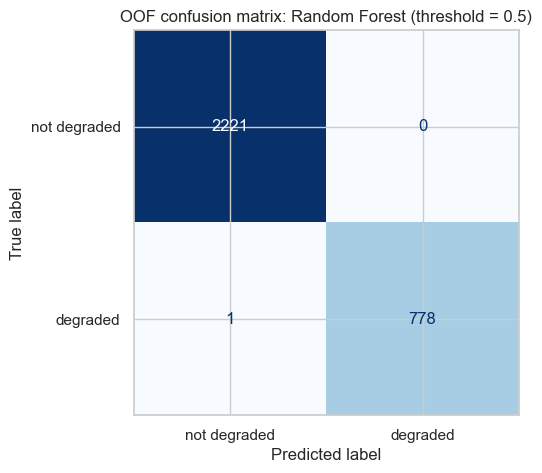

TN=2221, FP=0, FN=1, TP=778
False-positive rate: 0.000%
False-negative rate: 0.128%


In [14]:
cm = confusion_matrix(y_cls, best_cls_pred)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=["not degraded", "degraded"]).plot(
    ax=ax, cmap="Blues", colorbar=False
)
ax.set_title(f"OOF confusion matrix: {best_cls_name} (threshold = 0.5)")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"False-positive rate: {fp/(fp+tn):.3%}")
print(f"False-negative rate: {fn/(fn+tp):.3%}")

In [15]:
error_type = np.select(
    [(y_cls.to_numpy() == 0) & (best_cls_pred == 1),
     (y_cls.to_numpy() == 1) & (best_cls_pred == 0)],
    ["FP", "FN"], default="Correct"
)
cls_error_frame = X.copy()
cls_error_frame["actual"] = y_cls.to_numpy()
cls_error_frame["probability_degraded"] = best_cls_proba
cls_error_frame["error_type"] = error_type

display(cls_error_frame.loc[cls_error_frame["error_type"] != "Correct"].sort_values("CycleNumber"))

,CycleNumber,Voltage(V),Current(A),Temperature(C),Cell1_V,Cell2_V,Cell3_V,Cell4_V,Cell5_V,Cell6_V,Cell7_V,Cell8_V,actual,probability_degraded,error_type
2221,2222,25.522295,-32.060987,26.518859,3.191676,3.198235,3.20285,3.192873,3.202338,3.201095,3.200375,3.194784,1,0.441529,FN


### 4.2 Probability-based analysis

The probability distributions reveal calibration and confidence. High-confidence errors are FPs with probabilities near 1 or FNs with probabilities near 0.

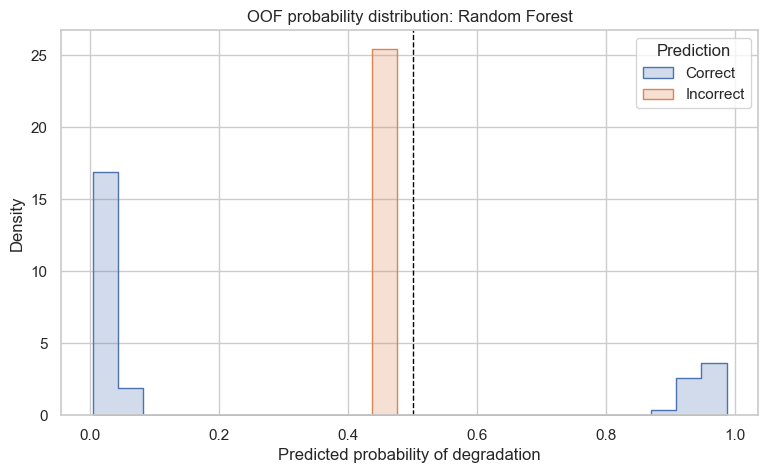

High-confidence errors (confidence >= 0.80): 0


,CycleNumber,Voltage(V),Current(A),Temperature(C),Cell1_V,Cell2_V,Cell3_V,Cell4_V,Cell5_V,Cell6_V,Cell7_V,Cell8_V,actual,probability_degraded,error_type,prediction_confidence


In [16]:
prob_frame = pd.DataFrame({
    "Predicted probability of degradation": best_cls_proba,
    "Prediction": np.where(correct, "Correct", "Incorrect"),
})
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(data=prob_frame, x="Predicted probability of degradation", hue="Prediction",
             bins=25, stat="density", common_norm=False, element="step", ax=ax)
ax.axvline(.5, color="black", linestyle="--", linewidth=1)
ax.set_title(f"OOF probability distribution: {best_cls_name}")
plt.show()

confidence = np.where(best_cls_pred == 1, best_cls_proba, 1 - best_cls_proba)
high_conf_errors = cls_error_frame.loc[(~correct) & (confidence >= .8)].copy()
high_conf_errors["prediction_confidence"] = confidence[(~correct) & (confidence >= .8)]
print("High-confidence errors (confidence >= 0.80):", len(high_conf_errors))
display(high_conf_errors.sort_values("prediction_confidence", ascending=False).head(20))

### 4.3 Error as a function of features

Feature distributions for correct and incorrect predictions locate regions that are prone to misclassification.

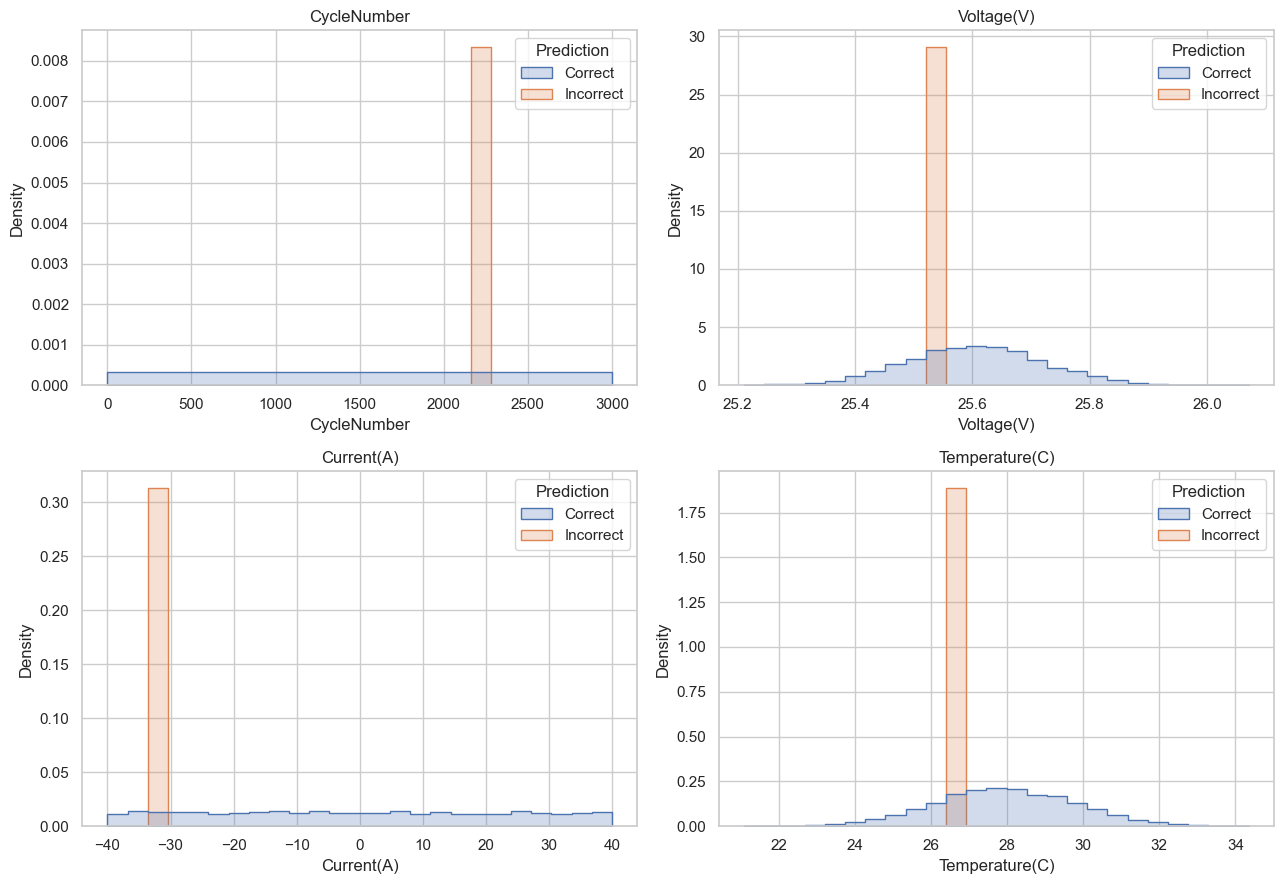

Prediction               Correct    Incorrect
CycleNumber    mean  1500.259420  2222.000000
               std    866.213920          NaN
Voltage(V)     mean    25.603867    25.522295
               std      0.118427          NaN
Current(A)     mean    -0.405472   -32.060987
               std     23.043063          NaN
Temperature(C) mean    27.968239    26.518859
               std      1.872676          NaN
Cell1_V        mean     3.200216     3.191676
               std      0.008049          NaN
Cell2_V        mean     3.199913     3.198235
               std      0.007741          NaN
Cell3_V        mean     3.199957     3.202850
               std      0.008027          NaN
Cell4_V        mean     3.199855     3.192873
               std      0.007777          NaN
Cell5_V        mean     3.199954     3.202338
               std      0.008048          NaN
Cell6_V        mean     3.199975     3.201095
               std      0.007868          NaN
Cell7_V        mean     3.199934     3.200375
               std      0.008250          NaN
Cell8_V        mean     3.200148     3.194784
               std      0.007941          NaN

In [17]:
feature_compare = X.copy()
feature_compare["Prediction"] = np.where(correct, "Correct", "Incorrect")
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, feature in zip(axes.flat, ["CycleNumber", "Voltage(V)", "Current(A)", "Temperature(C)"]):
    sns.histplot(data=feature_compare, x=feature, hue="Prediction", stat="density",
                 common_norm=False, element="step", bins=25, ax=ax)
    ax.set_title(feature)
plt.tight_layout()
plt.show()

display(feature_compare.groupby("Prediction")[FEATURES].agg(["mean", "std"]).T)

### 4.4 Threshold sensitivity

Thresholds from 0.1 through 0.9 show the precision-recall trade-off. We also track F1 and MCC. ROC-AUC is threshold-independent and summarizes ranking quality.

,Threshold,Precision,Recall,F1,MCC,FP,FN
0,0.100,0.994,1.000,0.997,0.996,5,0
1,0.200,0.997,1.000,0.999,0.998,2,0
2,0.300,0.997,1.000,0.999,0.998,2,0
3,0.400,0.999,1.000,0.999,0.999,1,0
4,0.500,1.000,0.999,0.999,0.999,0,1
5,0.600,1.000,0.999,0.999,0.999,0,1
6,0.700,1.000,0.999,0.999,0.999,0,1
7,0.800,1.000,0.999,0.999,0.999,0,1
8,0.900,1.000,0.965,0.982,0.977,0,27


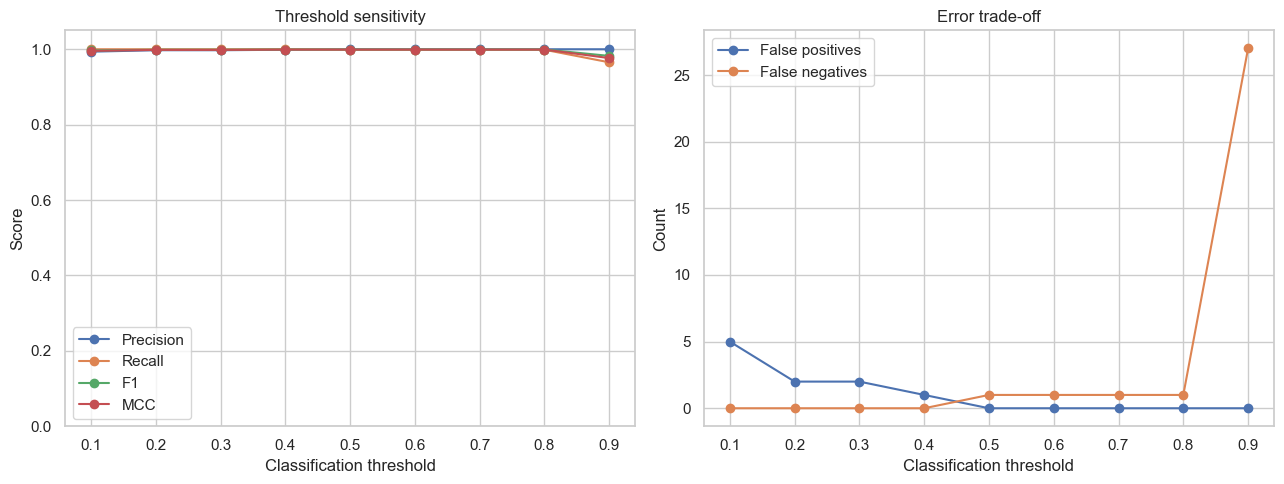

In [18]:
threshold_rows = []
for threshold in np.arange(.1, 1.0, .1):
    pred = (best_cls_proba >= threshold).astype(int)
    threshold_rows.append({
        "Threshold": threshold,
        "Precision": precision_score(y_cls, pred, zero_division=0),
        "Recall": recall_score(y_cls, pred, zero_division=0),
        "F1": f1_score(y_cls, pred, zero_division=0),
        "MCC": matthews_corrcoef(y_cls, pred),
        "FP": ((y_cls.to_numpy() == 0) & (pred == 1)).sum(),
        "FN": ((y_cls.to_numpy() == 1) & (pred == 0)).sum(),
    })
threshold_results = pd.DataFrame(threshold_rows)
display(threshold_results.style.format({c: "{:.3f}" for c in ["Threshold", "Precision", "Recall", "F1", "MCC"]}))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for metric in ["Precision", "Recall", "F1", "MCC"]:
    axes[0].plot(threshold_results["Threshold"], threshold_results[metric], marker="o", label=metric)
axes[0].set(xlabel="Classification threshold", ylabel="Score", ylim=(0, 1.05), title="Threshold sensitivity")
axes[0].legend()

axes[1].plot(threshold_results["Threshold"], threshold_results["FP"], marker="o", label="False positives")
axes[1].plot(threshold_results["Threshold"], threshold_results["FN"], marker="o", label="False negatives")
axes[1].set(xlabel="Classification threshold", ylabel="Count", title="Error trade-off")
axes[1].legend()
plt.tight_layout()
plt.show()

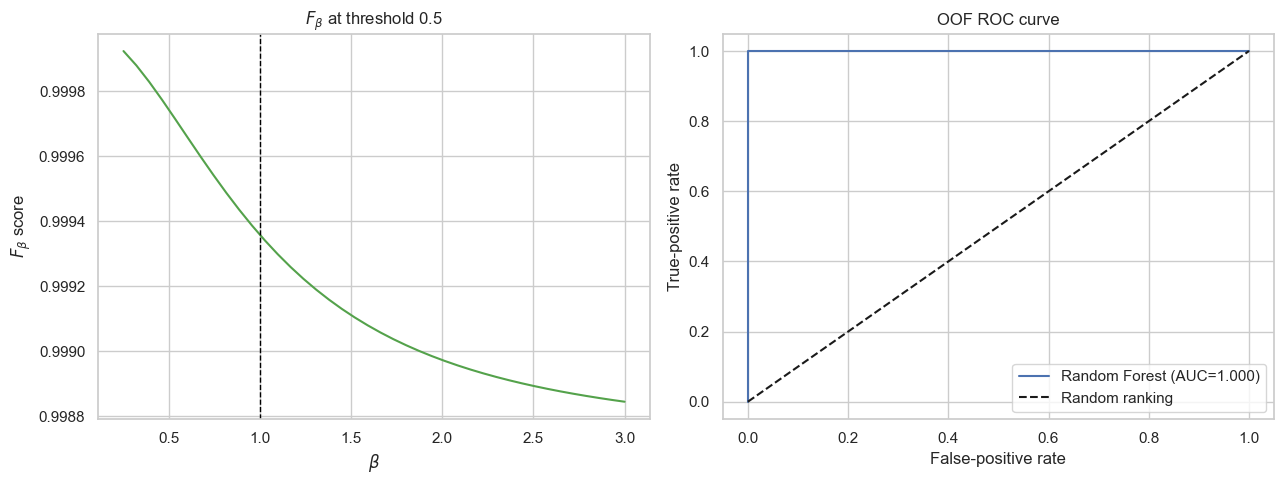

In [19]:
betas = np.linspace(.25, 3, 40)
beta_scores = []
for beta in betas:
    beta_scores.append(fbeta_score(y_cls, best_cls_pred, beta=beta, zero_division=0))

fpr, tpr, _ = roc_curve(y_cls, best_cls_proba)
roc_auc = roc_auc_score(y_cls, best_cls_proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(betas, beta_scores, color="#54A24B")
axes[0].set(xlabel=r"$\beta$", ylabel=r"$F_\beta$ score", title=r"$F_\beta$ at threshold 0.5")
axes[0].axvline(1, color="black", linestyle="--", linewidth=1)

axes[1].plot(fpr, tpr, label=f"{best_cls_name} (AUC={roc_auc:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", label="Random ranking")
axes[1].set(xlabel="False-positive rate", ylabel="True-positive rate", title="OOF ROC curve")
axes[1].legend()
plt.tight_layout()
plt.show()

In [20]:
best_f1_row = threshold_results.loc[threshold_results["F1"].idxmax()]
best_mcc_row = threshold_results.loc[threshold_results["MCC"].idxmax()]
recall_candidates = threshold_results[threshold_results["Recall"] >= .95]
safe_row = recall_candidates.sort_values(["Precision", "MCC"], ascending=False).head(1)

print(f"Best tested F1 threshold: {best_f1_row['Threshold']:.1f} (F1={best_f1_row['F1']:.3f})")
print(f"Best tested MCC threshold: {best_mcc_row['Threshold']:.1f} (MCC={best_mcc_row['MCC']:.3f})")
if not safe_row.empty:
    row = safe_row.iloc[0]
    print(f"High-recall candidate: {row['Threshold']:.1f} (recall={row['Recall']:.3f}, precision={row['Precision']:.3f})")

Best tested F1 threshold: 0.4 (F1=0.999)
Best tested MCC threshold: 0.4 (MCC=0.999)
High-recall candidate: 0.5 (recall=0.999, precision=1.000)


### 4.5 Classification discussion

- **Strengths and limitations:** The Random Forest and Decision Tree both achieve `99.97%` accuracy and make one FN with no FP at threshold 0.5. The forest has `MCC = 0.9991` and `ROC-AUC = 1.0000`. Logistic Regression is less accurate (`98.33%`) but still ranks cases extremely well (`ROC-AUC = 0.9999`), showing that most of its errors come from the chosen decision boundary rather than poor ordering.
- **Critical error:** A false negative is more consequential because an actually degraded battery is treated as healthy. A lower threshold can reduce FNs, but increases unnecessary alerts.
- **Systematic failure region:** The only error at threshold 0.5 is cycle 2222, the first observation just across the `SOH = 80%` boundary. It is predicted with degradation probability `0.442`, so it is a low-confidence boundary error, not an unexplained high-confidence failure. This is mainly a formulation issue: a continuous process is converted into a hard label.
- **Stable operating regions:** Thresholds 0.4-0.8 are very stable, with F1 and MCC near 0.999. Threshold 0.4 removes the FN at the cost of one FP and maximizes both tested F1 and MCC. Threshold 0.9 is unstable for recall and creates 27 FNs.
- **High-confidence errors:** There are no incorrect predictions with confidence at least 0.80. This reduces concern about confidently wrong regions in this dataset, but does not establish calibration on new battery packs.
- **Proxy risk:** `CycleNumber` can dominate because the dataset contains one battery pack following one degradation trajectory. Performance may not generalize to other packs or operating regimes.

## 5. Final reflection

1. **Where do the models fail most?** Regression errors concentrate late in battery life: 128 of the 150 largest errors occur after cycle 1800. The classifier's single error is exactly at cycle 2222, the first degraded case across the 80% SOH boundary.
2. **Data, model, or formulation?** All three contribute, but the observed failures are mainly model/formulation effects. The tree approximates a smooth, steepening degradation curve with constant-valued leaves, while the binary target creates an artificial boundary. The single-pack sequential dataset limits the strength of any generalization claim, and deterministic derived columns create severe leakage risk if used carelessly.
3. **Proposed improvements:** Collect multiple battery packs under varied loads and temperatures; validate with grouped or forward-chaining splits; add physically meaningful rolling/lag features available at prediction time; tune hyperparameters within nested CV; calibrate classification probabilities; and choose the threshold from explicit FN/FP costs.
4. **Main insights:** Cross-validated aggregate metrics are only a starting point. Residual shape, extreme cases, probability confidence, feature-conditioned errors, and threshold sensitivity reveal whether a good average score represents robust behavior. Leakage control and validation design can matter more than choosing a more complex algorithm.

## Reproducibility note

Every random component uses seed 42, all predictions used for reported metrics are OOF, and all models use the same predictor set within each task. The regression and classification targets require different exclusions because capacity directly determines the degradation label.